# <span style="color: Coral;"> Scenario config UI </span>

- Load the <span style="color: orange;"> _utils_ </span> module, which handles the backend functions to provide the <span style="color: blue;"> __scenario comnfig ui__ </span> 

In [1]:
import bcnexus.utils as utils
import re # For regex operations
scenarios_dd, storage_algo_dd, h_grouping_dd, n_clusters_dd, timeslices_label = utils.build_scenario_ui()

- Assign the <span style="color: orange;"> __values__</span>  from <span style="color: blue;"> __scenario UI dropdowns__</span> to <span style="color: orange;"> __arguments__</span> 

In [2]:
model_builder_args = dict(
    run_scenario=scenarios_dd.value ,
    storage_algorithm=storage_algo_dd.value,
    clustering_attributes=dict(
        hour_grouping=h_grouping_dd.value,
        n_clusters=n_clusters_dd.value
    )
)


# We use the Timeslices information to access run specific folders
timeslices_int = int(re.search(r'\d+', timeslices_label.value).group()) if re.search(r'\d+', timeslices_label.value) else None


# <span style="color: Coral;"> Model Runner Object </span>

* <span style="color: grey;">From `clews.runner` module, load the `RunModel` Object </span>  

In [18]:
from bcnexus.clews.runner import RunModel

* <span style="color: grey;"> Create an instance of the `RunModel` Object `bcnexusRun` with __model_builder_args__ </span>  

In [ ]:
bcnexusRun = RunModel(**model_builder_args)

└> Initiated CLEWs Model Runner for 'Base_CNZ' scenario with 'Kotzur' storage algorithm
 └>  Input CSVS set to: data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs
____________________________________________________________________________________________________
     CLEWs Model Builder
____________________________________________________________________________________________________
******************
Scenario: Base_CNZ
******************
ℹ️  Using configuration file at: config/scenarios_bcnexus.yaml
ℹ️  Clustering attributes: {'hour_grouping': 12, 'n_clusters': 5}
ℹ️  Storage Algorithm: Kotzur
 └> Extracting class attributes e.g. directories, static values/ranges, constants etc.
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE config from : models/model_Kotzur/otoole_config_Kotzur.yaml
 └> checking input CSVs...
 └> Copying missing CSV files :


  └─> Skipped (already exists): TECHNOLOGY.csv
 └> Checked and copied missing CSV files from data/clews_data/csv_template to data/clews_data/clews_build_data/input_csvs
ℹ️  bcnexus.attributes_parser | Fetching OTOOLE config from : models/model_Kotzur/otoole_config_Kotzur.yaml
ℹ️  bcnexus.attributes_parser | BCNexus CLEWs model is structured as SINGLE region model. Current region set to: REGION1.
 └> Calculating clustering attributes
 └> No. of Timeslices configured= 10
  └─> Representative days: [204, 206, 230, 231, 253]


### 🚀 `run()` — Core Execution Workflow

* <span style="color: grey;"> Apply the `run()` method from  `bcnexusRun` instance </span> to run the complete workflow

About __Arguments__ of the `run()` method:

- `build=True` argument handles the workflow run to build SETs, Ratios, template params etc.
- `include_livestock` handles the livestock modelling workflow using `bcnexus/clews/livestock.py` module.
- `thread` depends on the hardware limitations of your machine. If you have 4 core CPU, use Thread __<=4__ )

* <span style="color: skyblue;"> Where do I get `threads` number ?</span>  
  - <span style="color: grey;"> Apply the `check_machine_cores()` function from  `utils` module. it returns the __number of cores available__ </span>  

In [5]:
n_physical_cores, n_logical_cores=utils.check_machine_cores()

ℹ️  Your machine has 24 physical cores and 32 logical cores.


| Model Characteristics                         | Recommended Threads | Reasoning                                                      |
| --------------------------------------------- | ------------------- | -------------------------------------------------------------- |
| Small LP/MILP (<50k vars)                     | 1–4                 | Over-parallelization adds overhead; single-thread often enough |
| Medium MILP (50k–500k vars)                   | 4–8                 | Good balance of parallel speed-up and stability                |
| Large/complex MILP (>500k vars, branch-heavy) | 8–16                | Parallel branch-and-bound scales moderately well               |
| Nonlinear / Quadratic / MIQP                  | 4–8                 | Solvers often rely on sequential matrix operations             |
| Highly degenerate or network-based LP         | 1–4                 | Parallel simplex often unstable; dual simplex preferred        |


* <span style="color: orange;">  Now run the Model ! </span>  

 <span style="color: coral;"> Important Notes:
  - While creating an instance of `RunModel` object (here named as `bcnexusRun`), it also creates an instance of `BuildModel` object (initiated and named as `ClewsBuilder` inside `RunModel` object ). You can access it via `bcnexusRun.ClewsBuilder`  , and access the methods inside `ClewsBuilder` object. 
  - The `ClewsBuilder` object can be found at </span> <span style="color: biege;"> bcnexus/clews/__builder.py__ module
  - when we set `build=True`. We use the `build()` method of `ClewsBuilder` object.
    - The `build()` method is useful to test/validate new structural changes to the model. This method handles the SETs creation, collection of LandCluster data, technology updates via clews_builder.yaml config. Refer to the script and the example workbook for more details on this object and methods.
    - `ClewsBuilder` has an explicit method `build_SETs_and_ratios` which is an adaptation of the former __clewsy__ tool. Developers can use this method and add their custom methods to incorporate new structural changes to the model.

<span style="color: coral;"> Data flow in folder:</span>
  - Everything happens inside : <span style="color: coral;"> data/clews_data</span>
  - The workflow __creates this directory__ : <span style="color: coral;">data/clews_data/<span style="color: magenta;">clews_build_data </span><br>
      <span style="color: grey;"> It has 3 sub-folders: 
      <span style="color: coral;">
      - input_csvs  <span style="color: grey;">: The workflow collects templates data first, then updates the files accordingly to reflect changes in clews_builder.yaml config. <span style="color: red;"> if `build`=False, then the workflow assumes all files are updated in this folder. Once you build the model structure, to adjust the temporal clustering attributes only, you can set `build=False`, to skip the steps to build this folder.
      - inputs_csv_8760<span style="color: grey;">: Creates BCNexus compatible profiling parameters in hourly resolution. Which are used to apply the clustering. <span style="color: red;"> if `build`=False, then the workflow assumes all files are updated in this folder.Once you build the model structure, to adjust the temporal clustering attributes only, you can set `build=False`, to skip the steps to build this folder.
      - Model_storage_algorithm<span style="color: grey;">: Final datafiles are stored inside this folder with storage case, and sub-folders with scenarios. 
  - Once you build the model structure, yt adjust the clustering attributes only, you can set `build=False`, to skip the steps to build this folder.


└>  Running CLEWs Builder to prepare SETs and Params for scenario: Base_CNZ 
└> Building SETs and Ratios data...
 └> Collecting LandCluster data files...
⚠️  This model usages prepared LandCluster data. Ensure the data is prepared for the scenario being modelled.
ℹ️  Landcluster data source: models/LandClusterData
 └> Copying all CSV files : 'models/LandClusterData' >> 'data/clews_data/LandClusterData'
  └> Copied: clustering_results_prc_BC1.csv
  └> Copied: clustermap_table.csv
  └> Copied: clustering_results_BC1.csv
  └> Copied: clustering_results_evt_BC1.csv
  └> Copied: clustering_results_cwd_BC1.csv
*******************
Building CLEWs SETs
*******************
ℹ️  Saving to directory: data/clews_data/SETs
ℹ️  Model Structure: 'bcnexus/clews/model_structure.py'
  └> Checking Land Cluster Data files...
  └─> landcluser data source: data/clews_data/LandClusterData
  └─> ✔ All cluster files for land region 'BC1' found.
⚠️  Warning:  Import fuel CRU created for fuel that is not used in a

2025-11-19 16:18:36,723 - INFO - Set parameter Username


Set parameter LicenseID to value 2606744


2025-11-19 16:18:36,724 - INFO - Set parameter LicenseID to value 2606744


Academic license - for non-commercial use only - expires 2026-01-06


...

cost: 396160 rows, 408475 columns, 3937586 nonzeros


2025-11-19 16:18:38,138 - INFO - cost: 396160 rows, 408475 columns, 3937586 nonzeros


Set parameter LogToConsole to value 0


2025-11-19 16:18:38,139 - INFO - Set parameter LogToConsole to value 0
2025-11-19 16:18:38,139 - INFO - Set parameter Method to value 2
2025-11-19 16:18:38,139 - INFO - Set parameter Threads to value 32
2025-11-19 16:18:38,139 - INFO - Set parameter NumericFocus to value 0
2025-11-19 16:18:38,139 - INFO - Set parameter LogFile to value "results/clews/Model_Kotzur_Base_CNZ/10ts/gurobi.log"
2025-11-19 16:18:38,139 - INFO - Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 20.04.6 LTS")
2025-11-19 16:18:38,139 - INFO - 
2025-11-19 16:18:38,140 - INFO - CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
2025-11-19 16:18:38,140 - INFO - Thread count: 32 physical cores, 32 logical processors, using up to 32 threads
2025-11-19 16:18:38,140 - INFO - 
2025-11-19 16:18:38,140 - INFO - Non-default parameters:
2025-11-19 16:18:38,140 - INFO - Method  2
2025-11-19 16:18:38,140 - INFO - LogToConsole  0
2025-11-19 16:18:38,140 - INFO - Threads  32
2025-

  └> --------------------------------------------------
  └─> Model run completed. Please check the log for detailed report.
 └> Optimization successful. An optimal solution is available.
└> Writing the Solution to : results/clews/Model_Kotzur_Base_CNZ/10ts/10ts_solution_gurobi.sol
└> Extracting the shadow price of Electricity (ELCB02) from Electricity Balance Constraint
└> Preparing the summary reports for constraints, from solved model
  └> Collecting constraints reports...
  └> Summary saved to results/clews/Model_Kotzur_Base_CNZ/10ts/constraints_summary.txt
 └> Duals extracted and saved to csv @ results/clews/Model_Kotzur_Base_CNZ/10ts/EBa11_EnergyBalanceEachTS5_duals.csv 
└> Extracting results from Solution : results/clews/Model_Kotzur_Base_CNZ/10ts/10ts_solution_gurobi.sol
 └> Initiating otoole interface to extract results; input csvs : data/clews_data/clews_build_data/Model_Kotzur/storage_case_input_csvs , config file: models/model_Kotzur/otoole_config_Kotzur.yaml
  └> Result ex

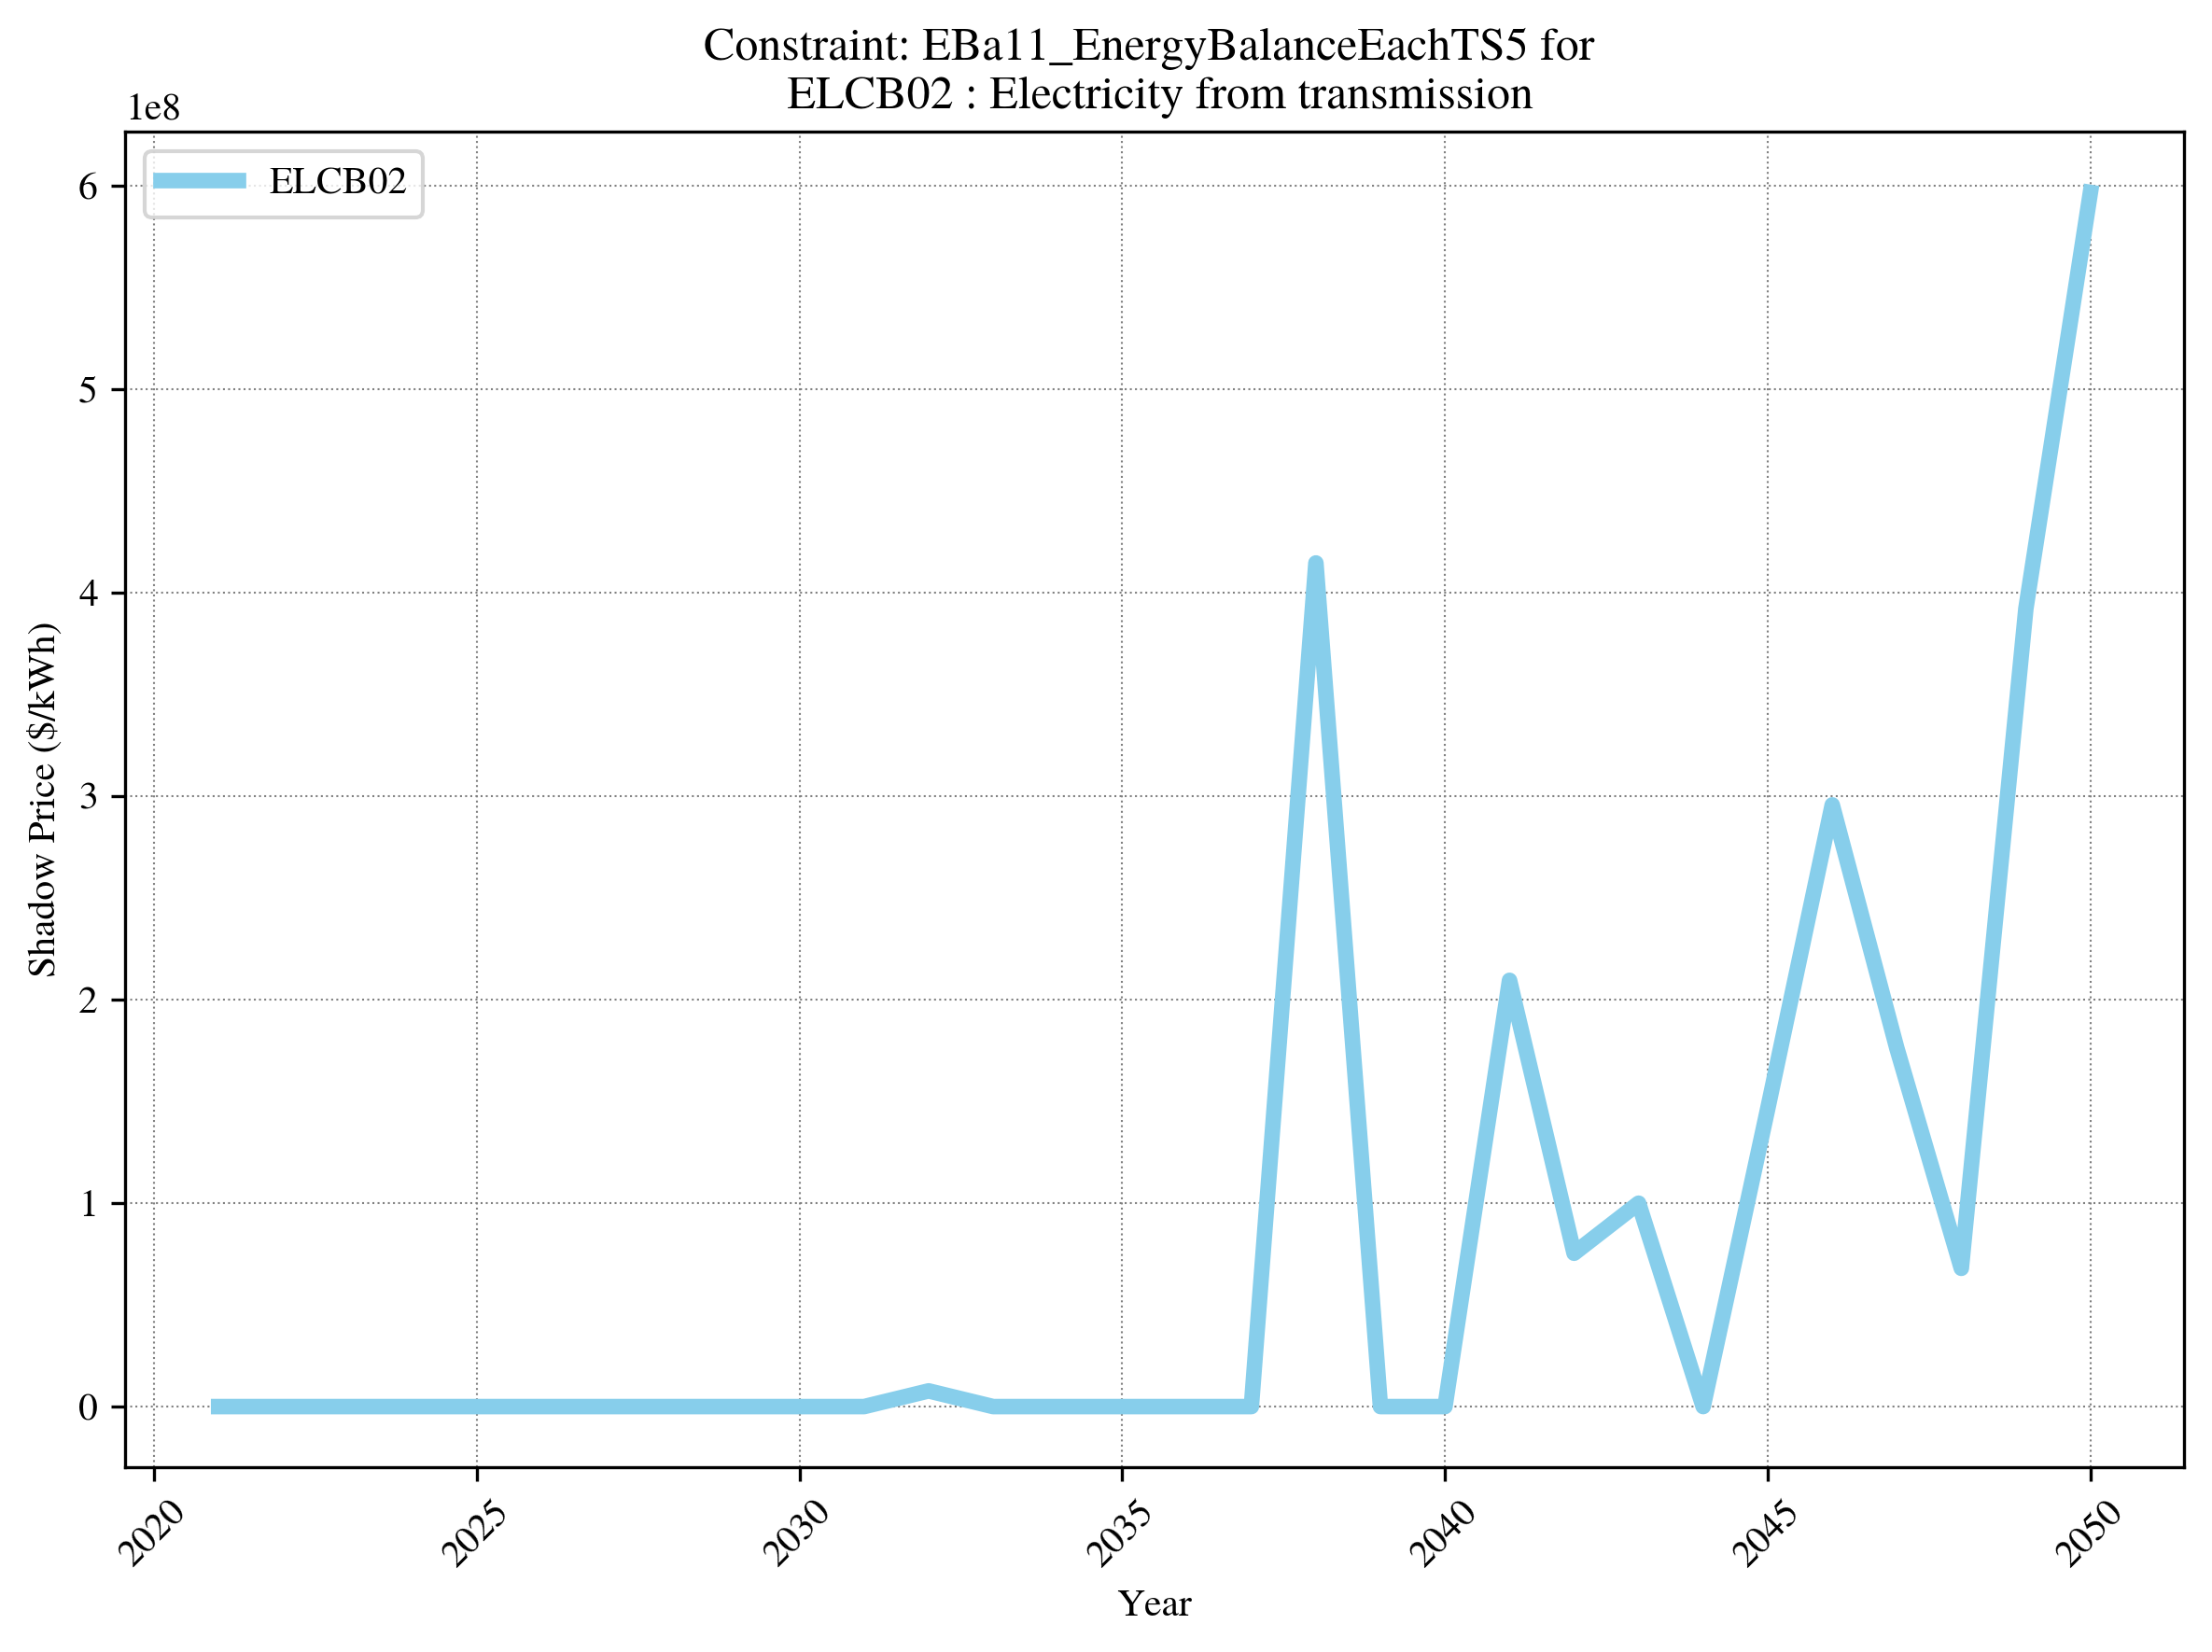

In [ ]:
bcnexusRun.run(build=True,
             include_livestock=False,
             threads=32) 

# <span style="color: Coral;"> Results </span>

### <span style="color: grey;"> Check Results @ `results\clews\<Model_<storage_algorithm>_<scenario>`</span>

- <span style="color: grey;"> We can also use the `datapackage` module's `GetDataPackage` object to load load the results as an object.
- <span style="color: grey;"> This results pack could be used for __post-analysis, result exchange to other models, visualizations, scenario dashes__ etc.

- <span style="color: grey;">  Get `result_pack` as an instance of `GetDataPackage` object

In [7]:
from bcnexus.clews.datapackage import GetDataPackage

nexus_results_root=f'results/clews/Model_{model_builder_args['storage_algorithm']}_{model_builder_args['run_scenario']}/{timeslices_int}ts_csvs_gurobi'
result_pack=GetDataPackage(nexus_results_root)
result_pack.show

└> Loaded 29 CSV files from results/clews/Model_Kotzur_Base_CNZ/10ts_csvs_gurobi


['AccumulatedNewCapacity',
 'AnnualEmissions',
 'AnnualFixedOperatingCost',
 'AnnualTechnologyEmission',
 'AnnualTechnologyEmissionByMode',
 'AnnualVariableOperatingCost',
 'CapitalInvestment',
 'Demand',
 'DiscountedSalvageValue',
 'DiscountedTechnologyEmissionsPenalty',
 'NewCapacity',
 'NewStorageCapacity',
 'ProductionByTechnology',
 'ProductionByTechnologyAnnual',
 'RateOfActivity',
 'RateOfProductionByTechnology',
 'RateOfProductionByTechnologyByMode',
 'RateOfUseByTechnology',
 'RateOfUseByTechnologyByMode',
 'SalvageValue',
 'SalvageValueStorage',
 'StorageLevelChronoDayStart',
 'StorageLevelDayTypeFinish',
 'StorageLevelYearStart',
 'TotalAnnualTechnologyActivityByMode',
 'TotalCapacityAnnual',
 'TotalTechnologyAnnualActivity',
 'TotalTechnologyModelPeriodActivity',
 'UseByTechnology']

- <span style="color: grey;">  Apply `get_dataframe(<Result param name>)` method of the `result_pack` instance

In [9]:
#example
result_pack.get_dataframe('CapitalInvestment')

,REGION,TECHNOLOGY,YEAR,VALUE
0,REGION1,DEMINDDSL,2021,0.030565
1,REGION1,DEMINDDSL,2022,0.030368
2,REGION1,DEMINDDSL,2023,0.031218
3,REGION1,DEMINDDSL,2024,0.031900
4,REGION1,DEMINDDSL,2025,0.032556
...,...,...,...,...
1675,REGION1,HDG02,2044,0.006342
1676,REGION1,HDG02,2046,0.006342
1677,REGION1,HDG02,2047,0.006342
1678,REGION1,HDG02,2048,0.006342


# <span style="color: yellow;"> Plots </span>

!! <span style="color: biege;"> Still under active development to include more comprehensive plots <span style="color: yellow;"> EL_20251119

- <span style="color: biege;">  Load the `plotter` module. 
  - <span style="color: grey;"> plotter.`get_plots()` function returns a dictionary of plots. You can review the plots in this notebook from that dictionary. The function also save the plots as html to 'vis/bccm/< scenario > '

In [5]:
import bcnexus.plots as plotter

plotter_args=dict(
    nexus_scenario=model_builder_args['run_scenario'],
    storage_algorithm=model_builder_args['storage_algorithm'],
    timeslices=timeslices_int,
)
# plotter.main(**plotter_args)
nexus_plots=plotter.get_plots(**plotter_args)

 └> No CSV files found in the directory.
└> Loaded 0 CSV files from results/clews/Model_Kotzur_Base_CNZ/10ts_csvs_gurobi
 └ ❌ > 'AnnualEmissions' not found in the loaded CSV files.
 └> AnnualEmissions Data empty for Base_CNZ
 └ ❌ > 'AnnualTechnologyEmission' not found in the loaded CSV files.
 └> AnnualTechnologyEmission Data empty for Base_CNZ
 └ ❌ > 'AnnualTechnologyEmission' not found in the loaded CSV files.
 └> AnnualTechnologyEmission Data empty for Base_CNZ
 └ ❌ > 'RateOfProductionByTechnologyByMode' not found in the loaded CSV files.


TypeError: 'NoneType' object is not subscriptable

In [4]:
nexus_plots.keys()

NameError: name 'nexus_plots' is not defined

# <span style="color: Coral;"> Playground for Solved Model </span>

* <span style="color: grey;">Load the Gurobi Model object as `m` from `clewsRun`'s attribute `solved_model` </span>  

In [12]:
m=clewsRun.solved_model

In [13]:
m.printStats()          # Print basic stats: number of vars, constraints, etc.

2025-11-19 17:13:31,111 - INFO - Statistics for model 'cost':
2025-11-19 17:13:31,113 - INFO -   Problem type                : LP
2025-11-19 17:13:31,114 - INFO -   Linear constraint matrix    : 396160 rows, 408475 columns, 3937586 nonzeros
2025-11-19 17:13:31,115 - INFO -   Variable types              : 408475 continuous, 0 integer (0 binary)
2025-11-19 17:13:31,116 - INFO -   Matrix range                : [3e-08, 1e+06]
2025-11-19 17:13:31,116 - INFO -   Objective range             : [2e-03, 2e+08]
2025-11-19 17:13:31,117 - INFO -   Bounds range                : [0e+00, 0e+00]
2025-11-19 17:13:31,118 - INFO -   RHS range                   : [1e-05, 1e+08]


In [14]:
m.getAttr('Obj')     # Get objective coefficients

[17300000.0,
 172999827.0,
 16476190.4761905,
 164761740.0,
 15691609.9773243,
 156915942.857143,
 14944390.4545945,
 149443755.102042,
 14232752.8138995,
 142327385.811467,
 13555002.6799044,
 135549891.249016,
 12909526.3618137,
 129095134.522873,
 12294787.0112511,
 122947747.164641,
 11709320.9630963,
 117093092.537753,
 11151734.2505679,
 111517230.988336,
 10620699.2862551,
 106206886.655558,
 10114951.7011954,
 101149415.862437,
 9633287.33447175,
 96332777.0118442,
 9174559.36616357,
 91745501.9160423,
 8737675.58682244,
 87376668.4914687,
 8321595.79697374,
 83215874.75378,
 7925329.3304512,
 79253214.0512188,
 7547932.69566783,
 75479251.4773513,
 7188507.32920748,
 71885001.407001,
 6846197.45638807,
 68461906.1019061,
 6520188.05370288,
 65201815.3351486,
 6209702.90828849,
 62096966.985856,
 5914002.76979854,
 59139968.5579576,
 5632383.59028435,
 56323779.5790073,
 5364174.84788983,
 53641694.8371501,
 5108737.95037127,
 51087328.4163331,
 4865464.71463931,
 48654598.4917

In [15]:
m.getConstrs()          # List of all constraint objects

[<gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2021)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2022)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2023)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2024)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2025)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2026)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2027)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2028)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2029)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2030)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2031)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2032)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2033)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2034)>,
 <gurobi.Constr CAa1_TotalNewCapacity(REGION1,DEMINDDSL,2035)>,
 <gurobi.Constr CAa1_TotalNewCapacity(RE

#### <span style="color: orange;">  Define or Modify the Model </span> 

In [ ]:
# x = m.addVar(lb=0, ub=10, obj=3, name='x')
# y = m.addVar(lb=0, ub=GRB.INFINITY, obj=1, name='y')
# m.addConstr(2*x + 3*y >= 10, name='demand_constraint')
# m.setObjective(3*x + 1*y, GRB.MINIMIZE)


* <span style="color: grey;">Load the `plotter` module and use the `main()` function </span>